# Data description

In [17]:

import os
import sys
import importlib
from importlib import reload 
from dataclasses import dataclass, field, fields
from itertools import compress
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from cycler import cycler

import scipy
import scipy.io as sio
from scipy import signal
from scipy.signal import spectrogram, hann, butter, filtfilt, freqz
from scipy import stats
from scipy.stats import norm
from scipy.stats import ttest_ind

import seaborn as sns
import pingouin as pg
import itertools
from itertools import combinations
from statannotations.Annotator import Annotator
import statsmodels.api as sm
import statsmodels.formula.api as smf
from patsy import dmatrices
import plotly.express as px

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, GridSearchCV
from sklearn.metrics import classification_report

# import openpyxl
# from openpyxl import Workbook, load_workbook
# import xlrd
import pickle
import json
import csv

#mne
import mne_bids
import mne
from mne.time_frequency import tfr_morlet 
from mne.stats import permutation_cluster_test


# TODO: add README file: 
# pip install pingouin
# pip install statannotations
# pip install fooof

In [396]:
jennifer_user_path = os.getcwd()
while jennifer_user_path[-14:] != 'jenniferbehnke':
    jennifer_user_path = os.path.dirname(jennifer_user_path)

# directory to this Repository
project_path = os.path.join(jennifer_user_path, 'code', 'BetaSenSightLongterm', 'BetaSenSightLongterm')
sys.path.append(project_path)

os.chdir(project_path)

import src.bssu.utils.find_folders as find_folders
importlib.reload(find_folders)

# import PyPerceive

project_path = find_folders.chdir_repository("Py_Perceive")

from PerceiveImport.classes import (
    main_class, modality_class, metadata_class,
    session_class, condition_class, task_class,
    contact_class, run_class
)

import PerceiveImport.methods.load_rawfile as load_rawfile
import PerceiveImport.methods.find_folders as PyPerceive_find_folders
import PerceiveImport.methods.metadata_helpers as metaHelpers

# import meet

project_path = find_folders.chdir_repository("meet")

import meet as meet

# import all functions from BetaSenSightLongterm
project_path = find_folders.chdir_repository("BetaSenSightLongterm")

# tfr, processing
import src.bssu.tfr.BSSuPsd as BSSuPsd
import src.bssu.tfr.FastFourierPSD as FFpsd
import src.bssu.tfr.fooof_fit as fooof_fit

# bipolar Channel Analysis
import src.bssu.bipolar.power_spectra_plots as power_spectra_plots
import src.bssu.bipolar.PeakFrequencies_PSD as PeakFrequency_psd
import src.bssu.bipolar.BIP_channelGroups as BIP_channelGroups
import src.bssu.bipolar.BIP_perChannelAnalysis as BIP_perChannel


# monopolar Referencing
import src.bssu.monopolar.MonoRef_JLB as MonoRefJLB
import src.bssu.monopolar.GroupMonopolarPSD as groupMonopol
import src.bssu.monopolar.monoRef_weightPsdAverageByCoordinateDistance as MonoRefWeightedCoordinateDistance
import src.bssu.monopolar.externalized_lfp as externalized
import src.bssu.monopolar.monopol_method_comparison as monopol_comparison
import src.bssu.monopolar.bssu_contacts_maximal_beta as bssu_contacts
import src.bssu.monopolar.monoRef_Strelow as detec_strelow

# Ranking Order
import src.bssu.ranking.HighestRankedChannelPSD as highestRank
import src.bssu.ranking.monopolPSDaverage_withinSubject as PSDaverageMonopol
import src.bssu.ranking.BIPchannelGroups_ranks as BIP_ranks
import src.bssu.ranking.Permutation_rankings as Permute_ranks
import src.bssu.ranking.beta_rank_longitudinal_changes as beta_rank_change


# Clinical stimulation parameters
import src.bssu.stimulation.activeStimulationContacts as activeStimContacts

# utility functions
import src.bssu.utils.loadResults as loadResults
import src.bssu.utils.find_folders as find_folders
import src.bssu.utils.writeGroupDataframes as writeGroupDF
import src.bssu.utils.load_data_files as load_data
import src.bssu.utils.monopol_comparison_helpers as mono_comp_helpers
import src.bssu.utils.sub_session_dict as sub_session_dict
import src.bssu.utils.percept_helpers as helpers
# import Classes
from src.bssu.classes import (metadataAnalysis_class, mainAnalysis_class, sessionAnalysis_class, 
                              channelAnalysis_class, featureAnalysis_class, frequencyBand_class)

# import mni coordinates
import src.bssu.mni.load_rotated_coordinates as load_mni

# revision code
import src.bssu.revision.spatial_distribution as spatial_distribution


importlib.reload(BSSuPsd)
importlib.reload(MonoRefJLB)
importlib.reload(loadResults)
importlib.reload(highestRank)
importlib.reload(groupMonopol)
importlib.reload(PSDaverageMonopol)
importlib.reload(FFpsd)
importlib.reload(find_folders)
importlib.reload(metadataAnalysis_class)
importlib.reload(mainAnalysis_class)
importlib.reload(sessionAnalysis_class)
importlib.reload(channelAnalysis_class)
importlib.reload(featureAnalysis_class)
importlib.reload(frequencyBand_class)
importlib.reload(PeakFrequency_psd)
importlib.reload(power_spectra_plots)
importlib.reload(BIP_channelGroups)
importlib.reload(BIP_ranks)
importlib.reload(activeStimContacts)
importlib.reload(Permute_ranks)
importlib.reload(BIP_perChannel)
importlib.reload(load_mni)
importlib.reload(writeGroupDF)
importlib.reload(MonoRefWeightedCoordinateDistance)
importlib.reload(load_data)
importlib.reload(externalized)
importlib.reload(monopol_comparison)
importlib.reload(bssu_contacts)
importlib.reload(mono_comp_helpers)
importlib.reload(detec_strelow)
importlib.reload(beta_rank_change)
importlib.reload(sub_session_dict)
importlib.reload(helpers)
importlib.reload(fooof_fit)
importlib.reload(spatial_distribution)

Excel file loaded:  patient_metadata.xlsx 
loaded from:  /Users/jenniferbehnke/Dropbox/work/ResearchProjects/Monopolar_power_estimation/data


<module 'src.bssu.revision.spatial_distribution' from '/Users/jenniferbehnke/code/BetaSenSightLongterm/BetaSenSightLongterm/src/bssu/revision/spatial_distribution.py'>

In [33]:
# load if you want to see complete Dataframes
pd.set_option("display.max_rows", None)

## Steps to write data

In [ ]:
# add single fooof results to group fooof results
# fooof_all_subjects = fooof_fit.add_fooof_singles_to_group_data(sub_list=["017", "026", "040", "059", "060", 
#                                                                          "066", "069", "072",
#                                                                          "075", "081", "084"], 
#                                                                 fooof_version="v2")



In [ ]:
loaded_fooof_result = loadResults.load_pickle_group_result(filename="fooof_group_data_percept", fooof_version="v2")
loaded_fooof_result.loc[loaded_fooof_result["subject_hemisphere"] == "026_Right"]

In [ ]:
# load the pickle FOOOF group dataframe
# calculate beta average
# rank beta within a channel group

# ranked_beta_fooof_group_percept = fooof_fit.highest_beta_channels_fooof_percept(
#     fooof_spectrum="periodic_spectrum",
#     fooof_version="v2"
# )

In [ ]:
beta_rank_DF = loadResults.load_fooof_beta_ranks(
        fooof_spectrum="periodic_spectrum",
        fooof_version="v2",
        all_or_one_chan="beta_ranks_all",
        all_or_one_longterm_ses="one_longterm_session",
    )

beta_rank_DF.head()

## Load finalized FOOOF data

### FOOOF data per group

In [ ]:
# FOOOF data of all channels (15 channels per STN)

beta_rank_DF = loadResults.load_fooof_beta_ranks(
        fooof_spectrum="periodic_spectrum",
        fooof_version="v2",
        all_or_one_chan="beta_all",
        all_or_one_longterm_ses="one_longterm_session",
    )

beta_rank_DF.head()

,subject_hemisphere,session,bipolar_channel,fooof_error,fooof_r_sq,fooof_exponent,fooof_offset,fooof_power_spectrum,periodic_plus_aperiodic_power_log,fooof_periodic_flat,fooof_number_peaks,alpha_peak_CF_power_bandWidth,low_beta_peak_CF_power_bandWidth,high_beta_peak_CF_power_bandWidth,beta_peak_CF_power_bandWidth,gamma_peak_CF_power_bandWidth,beta_average
0,017_Right,fu3m,03,0.066416,0.98557,1.688615,1.332174,"[0.00767014426514212, 0.03351470878412366, 0.1...","[0.8243496620189412, 0.5308087522174064, 0.339...","[0.0004994452423981573, 0.004308872706144536, ...",4,"[nan, nan, nan]","[nan, nan, nan]","[28.987529527052935, 0.5952799100446403, 7.519...","[28.987529527052935, 0.5952799100446403, 7.519...","[nan, nan, nan]",0.073489
1,017_Right,fu3m,13,0.088264,0.96624,1.457102,1.030205,"[0.008159401337378469, 0.006371132823893344, 0...","[0.5924797149155441, 0.33626772579620084, 0.15...","[0.0009066008320197118, 0.0012775321970460254,...",4,"[nan, nan, nan]","[nan, nan, nan]","[29.225692476850114, 0.9213419411183563, 3.000...","[29.225692476850114, 0.9213419411183563, 3.000...","[nan, nan, nan]",0.150319
2,017_Right,fu3m,02,0.093521,0.971951,1.685157,1.420904,"[7.787614109133756e-09, 1.882592837176844e-08,...","[0.9136209432416069, 0.6168795782504854, 0.406...","[4.126367042459155e-10, 1.975427741277798e-09,...",3,"[nan, nan, nan]","[nan, nan, nan]","[29.073003972962415, 0.9881124104459198, 8.238...","[29.073003972962415, 0.9881124104459198, 8.238...","[nan, nan, nan]",0.254790
3,017_Right,fu3m,12,0.07857,0.972904,1.343522,0.757904,"[0.0003292927862230677, 0.0003079802974601531,...","[0.35352735458664525, 0.11698373243642358, -0....","[6.336812502902425e-05, 0.00010218204803303865...",4,"[nan, nan, nan]","[nan, nan, nan]","[29.43438184459086, 1.099716477148555, 4.71406...","[29.43438184459086, 1.099716477148555, 4.71406...","[nan, nan, nan]",0.204537
4,017_Right,fu3m,01,0.071117,0.979469,1.587926,1.157176,"[0.0260612717972748, 0.08068602780119916, 0.20...","[0.6815260508032184, 0.4132884933120965, 0.253...","[0.0023628423792285266, 0.01374512167041695, 0...",4,"[nan, nan, nan]","[nan, nan, nan]","[33.50000000000001, 0.34359567811682745, 3.000...","[33.50000000000001, 0.34359567811682745, 3.000...","[64.15854737876835, 0.19383025351969008, 10.73...",0.030401


In [16]:
beta_rank_DF.columns

Index(['subject_hemisphere', 'session', 'bipolar_channel', 'fooof_error',
       'fooof_r_sq', 'fooof_exponent', 'fooof_offset', 'fooof_power_spectrum',
       'periodic_plus_aperiodic_power_log', 'fooof_periodic_flat',
       'fooof_number_peaks', 'alpha_peak_CF_power_bandWidth',
       'low_beta_peak_CF_power_bandWidth', 'high_beta_peak_CF_power_bandWidth',
       'beta_peak_CF_power_bandWidth', 'gamma_peak_CF_power_bandWidth',
       'beta_average'],
      dtype='object')

In [342]:
loaded_fooof_monopolar_data = loadResults.select_fooof_data(
        dataset="monopolar_only_segmental",
        cohort="all_included"
    )


In [347]:
loaded_fooof_monopolar_data["fooof_data"].loc[loaded_fooof_monopolar_data["fooof_data"]["subject_hemisphere"] == "017_Right"]

,coord_z,coord_xy,session,subject_hemisphere,estimated_monopolar_beta_psd,contact,rank,beta_relative_to_max,beta_cluster,subject
1A,2.0+0.0j,0.650000+0.000000j,fu3m,017_Right,0.865548,1A,4.0,0.599964,2,017
1B,2.0+0.0j,-0.325000+0.562917j,fu3m,017_Right,0.802782,1B,6.0,0.556457,2,017
1C,2.0+0.0j,-0.325000-0.562917j,fu3m,017_Right,0.844396,1C,5.0,0.585302,2,017
2A,4.0+0.0j,0.650000+0.000000j,fu3m,017_Right,1.442667,2A,1.0,1.000000,1,017
2B,4.0+0.0j,-0.325000+0.562917j,fu3m,017_Right,1.189430,2B,3.0,0.824466,1,017
2C,4.0+0.0j,-0.325000-0.562917j,fu3m,017_Right,1.279271,2C,2.0,0.886740,1,017
1A,2.0+0.0j,0.650000+0.000000j,fu12m,017_Right,0.459436,1A,5.0,0.541168,2,017
1B,2.0+0.0j,-0.325000+0.562917j,fu12m,017_Right,0.353771,1B,6.0,0.416706,2,017
1C,2.0+0.0j,-0.325000-0.562917j,fu12m,017_Right,0.480602,1C,4.0,0.566099,2,017
2A,4.0+0.0j,0.650000+0.000000j,fu12m,017_Right,0.712674,2A,2.0,0.839456,1,017


Data description of all included FOOOF channels

In [31]:
selected_fooof_data = loadResults.select_fooof_data(dataset="bipolar_beta", cohort="all_included")
selected_fooof_data = selected_fooof_data["fooof_data"]

In [36]:
len(selected_fooof_data)

2376

In [29]:
### data description
def data_description(dataset:str, cohort:str):
    """
    Data description of FOOOF data
    """
    selected_fooof_data = loadResults.select_fooof_data(dataset=dataset,cohort=cohort)
    selected_fooof_data = selected_fooof_data["fooof_data"]

    # list of subjects
    subjects = list(selected_fooof_data.subject_hemisphere.str.split("_").str[0].unique())
    sub_hem_list = list(selected_fooof_data.subject_hemisphere.unique())

    print(
        f"Number of channels fitted: {len(selected_fooof_data.subject_hemisphere.values)}"
    )
    print(f"List of STNs: {list(selected_fooof_data.subject_hemisphere.unique())}")
    print(
        f"Number of STNs: {len(selected_fooof_data.subject_hemisphere.unique())}",
        "\nNumber of patients: "
        + (str(len(selected_fooof_data.subject_hemisphere.unique()) / 2)),
    )

    # mean, std, sem of fooof error and r squared
    mean_fooof_error = np.mean(selected_fooof_data["fooof_error"])
    std_fooof_error = np.std(selected_fooof_data["fooof_error"])
    sem_fooof_error = stats.sem(selected_fooof_data["fooof_error"])

    mean_fooof_r_sq = np.mean(selected_fooof_data["fooof_r_sq"])
    std_fooof_r_sq = np.std(selected_fooof_data["fooof_r_sq"])
    sem_fooof_r_sq = stats.sem(selected_fooof_data["fooof_r_sq"])

    print(f"FOOOF error mean: {mean_fooof_error},",
        f"\nFOOOF error standard deviation: {std_fooof_error},",
        f"\nFOOOF error sem: {sem_fooof_error},",

        f"\n\nFOOOF r squared mean: {mean_fooof_r_sq}",
        f"\nFOOOF r squared standard deviation: {std_fooof_r_sq},",
        f"\nFOOOF r squared sem: {sem_fooof_r_sq}")
    
    return {
        "subjects": subjects,
        "sub_hem_list": sub_hem_list,
        "selected_fooof_data": selected_fooof_data
    }

In [39]:
data = data_description(dataset="bipolar_beta", cohort="all_included")


Number of channels fitted: 2376
List of STNs: ['017_Right', '017_Left', '019_Right', '019_Left', '021_Right', '021_Left', '024_Right', '024_Left', '025_Right', '025_Left', '026_Right', '026_Left', '028_Right', '028_Left', '029_Right', '029_Left', '030_Right', '030_Left', '031_Right', '031_Left', '032_Right', '032_Left', '033_Right', '033_Left', '038_Right', '038_Left', '040_Right', '040_Left', '041_Right', '041_Left', '047_Right', '047_Left', '048_Right', '048_Left', '049_Right', '049_Left', '050_Right', '050_Left', '052_Right', '052_Left', '055_Right', '055_Left', '059_Right', '059_Left', '060_Right', '060_Left', '061_Right', '061_Left', '062_Right', '062_Left', '063_Right', '063_Left', '065_Right', '065_Left', '066_Right', '066_Left', '069_Right', '069_Left', '072_Right', '072_Left', '075_Right', '075_Left', '081_Right', '081_Left', '084_Right', '084_Left']
Number of STNs: 66 
Number of patients: 33.0
FOOOF error mean: 0.07600739296170349, 
FOOOF error standard deviation: 0.012902894

In [ ]:
data = data_description(dataset="bipolar_beta", cohort="group_1")

Number of channels fitted: 1080
List of STNs: ['024_Right', '024_Left', '025_Right', '025_Left', '026_Right', '026_Left', '029_Right', '029_Left', '030_Right', '030_Left', '059_Right', '059_Left', '061_Right', '061_Left', '062_Right', '062_Left', '063_Right', '063_Left', '066_Right', '066_Left', '069_Right', '069_Left', '072_Right', '072_Left', '075_Right', '075_Left', '081_Right', '081_Left', '084_Right', '084_Left']
Number of STNs: 30 
Number of patients: 15.0
FOOOF error mean: 0.0759839413939282, 
FOOOF error standard deviation: 0.013131765004552941, 
FOOOF error sem: 0.0003997720065422664, 

FOOOF r squared mean: 0.9612746241104947 
FOOOF r squared standard deviation: 0.028627920059184502, 
FOOOF r squared sem: 0.0008715234426768823


In [41]:
# how many channels have identified a peak in low beta, high beta or beta
# Function to count lists with floats for each column
def count_identified_peaks(beta_range_column: pd.Series):
    return sum(isinstance(row, np.ndarray) and not np.all(np.isnan(row)) for row in beta_range_column)

def count_identified_double_peaks(fooof_data: pd.DataFrame):
    peak_results = {
        "subject_hemisphere": [],
        "session": [],
        "bipolar_channel": [],
        "low_beta_peak_CF": [],
        "low_beta_peak_power": [],
        "high_beta_peak_CF": [],
        "high_beta_peak_power": []
    }
    
    for row in fooof_data.iterrows():
        if isinstance(row[1]["low_beta_peak_CF_power_bandWidth"], np.ndarray) and not np.all(np.isnan(row[1]["low_beta_peak_CF_power_bandWidth"])) and isinstance(row[1]["high_beta_peak_CF_power_bandWidth"], np.ndarray) and not np.all(np.isnan(row[1]["high_beta_peak_CF_power_bandWidth"])):
            # append to dictionary if there is a peak in both columns
            peak_results["subject_hemisphere"].append(row[1]["subject_hemisphere"])
            peak_results["session"].append(row[1]["session"])
            peak_results["bipolar_channel"].append(row[1]["bipolar_channel"])
            peak_results["low_beta_peak_CF"].append(row[1]["low_beta_peak_CF_power_bandWidth"][0])
            peak_results["low_beta_peak_power"].append(row[1]["low_beta_peak_CF_power_bandWidth"][1])
            peak_results["high_beta_peak_CF"].append(row[1]["high_beta_peak_CF_power_bandWidth"][0])
            peak_results["high_beta_peak_power"].append(row[1]["high_beta_peak_CF_power_bandWidth"][1])
    
    return pd.DataFrame(peak_results), len(peak_results["subject_hemisphere"])

# count identified peaks only if there is a peak in both columns



In [ ]:
selected_fooof_data = loadResults.select_fooof_data(dataset="bipolar_beta", cohort="all_included",)
selected_fooof_data = selected_fooof_data["fooof_data"]

double_peaks = count_identified_double_peaks(selected_fooof_data)
double_peaks[1]

303

In [42]:
def bar_plot_number_of_peaks(dataset:str, cohort:str, channel_group:str, session:str):
    """
    Bar plot of number of channels with identified peaks in low beta, high beta, beta

    Input:
        - dataset: str, "bipolar_beta", "bipolar_highest_beta" (only rank 1 channels per channel group)
        - cohort: str, "all_included", "group_1", "group_2", "group_3"
        - channel_group: str, "ring", "segm_inter", "segm_intra", "all_channels"
        - session: str, "fu3m", "all_sessions"
    """

    figures_path = find_folders.get_local_path(folder="GroupFigures")

    selected_fooof_data = loadResults.select_fooof_data(dataset=dataset,cohort=cohort)
    selected_fooof_data = selected_fooof_data["fooof_data"]

    # select for correct channel group
    if channel_group in {"ring", "segm_inter", "segm_intra"}:
        channel_group_dict = {"ring": ["01", "12", "23"],
                              "segm_inter": ["1A2A", "1B2B", "1C2C"],
                              "segm_intra": ["1A1B", "1A1C", "1B1C", "2A2B", "2A2C", "2B2C"]}

        selected_fooof_data = selected_fooof_data.loc[selected_fooof_data["bipolar_channel"].isin(channel_group_dict[channel_group])]

    else: 
        selected_fooof_data = selected_fooof_data
    
    # select for correct session
    if session in ["fu3m", "postop", "fu12m", "fu18or24m"]:
        selected_fooof_data = selected_fooof_data.loc[selected_fooof_data["session"] == session]
    
    else:
        selected_fooof_data = selected_fooof_data


    # count number of channels with identified peaks in low beta, high beta, beta
    low_beta_peaks = count_identified_peaks(selected_fooof_data["low_beta_peak_CF_power_bandWidth"])
    high_beta_peaks = count_identified_peaks(selected_fooof_data["high_beta_peak_CF_power_bandWidth"])
    beta_peaks = count_identified_peaks(selected_fooof_data["beta_peak_CF_power_bandWidth"])
    double_beta_peaks = count_identified_double_peaks(selected_fooof_data)[1]

    # count number of channels in the column
    total_channels = len(selected_fooof_data)

    # percentage of channels with identified peaks
    low_beta_peaks_percentage = (low_beta_peaks / total_channels) * 100
    high_beta_peaks_percentage = (high_beta_peaks / total_channels) * 100
    beta_peaks_percentage = (beta_peaks / total_channels) * 100
    double_peaks_percentage = (double_beta_peaks / total_channels) * 100

    # create a bar plot
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(
        ["Low Beta", "High Beta", "Beta", "Double Beta Peaks"],
        [low_beta_peaks_percentage, high_beta_peaks_percentage, beta_peaks_percentage, double_peaks_percentage],
        width=0.5,
        #color=["#1f77b4", "#ff7f0e", "#2ca02c"],
    )
    # # add numbers of channels with identified peaks at the top of the bars
    # for i, v in enumerate([low_beta_peaks, high_beta_peaks, beta_peaks]):
    #     ax.text(i, v, str(v), ha="center", va="bottom")

    ax.set_ylabel("Percentage of channels with identified peaks [%]")
    ax.set_title("Percentage of channels with identified peaks in low beta, high beta, beta")
    fig.tight_layout()

    fig.savefig(
            os.path.join(
                figures_path,
                f"revision_{cohort}_{dataset}_peak_numbers_barplot.png",
            ),
            bbox_inches="tight",
        )

    fig.savefig(
        os.path.join(
            figures_path,
            f"revision_{cohort}_{dataset}_peak_numbers_barplot.svg",
        ),
        bbox_inches="tight",
        format="svg",
    )

    print(f"low beta: {low_beta_peaks}",
    f"\nhigh beta: {high_beta_peaks}",
    f"\nbeta: {beta_peaks}",
    f"\ndouble beta peaks: {double_beta_peaks}"
    f"\ntotal channels: {total_channels}",
    f"\nlow beta percentage: {low_beta_peaks_percentage}",
    f"\nhigh beta percentage: {high_beta_peaks_percentage}",
    f"\nbeta percentage: {beta_peaks_percentage}",
    f"\ndouble beta peaks percentage: {double_peaks_percentage}")
    

    return {
        "low_beta_peaks": low_beta_peaks,
        "high_beta_peaks": high_beta_peaks,
        "beta_peaks": beta_peaks,
        "double_beta_peaks": double_beta_peaks,
        "total_channels": total_channels,
        "low_beta_peaks_percentage": low_beta_peaks_percentage,
        "high_beta_peaks_percentage": high_beta_peaks_percentage,
        "beta_peaks_percentage": beta_peaks_percentage,
        "double_beta_peaks_percentage": double_peaks_percentage,
    }

    

low beta: 1516 
high beta: 2042 
beta: 2227 
double beta peaks: 1372
total channels: 2376 
low beta percentage: 63.804713804713806 
high beta percentage: 85.94276094276094 
beta percentage: 93.72895622895624 
double beta peaks percentage: 57.744107744107744


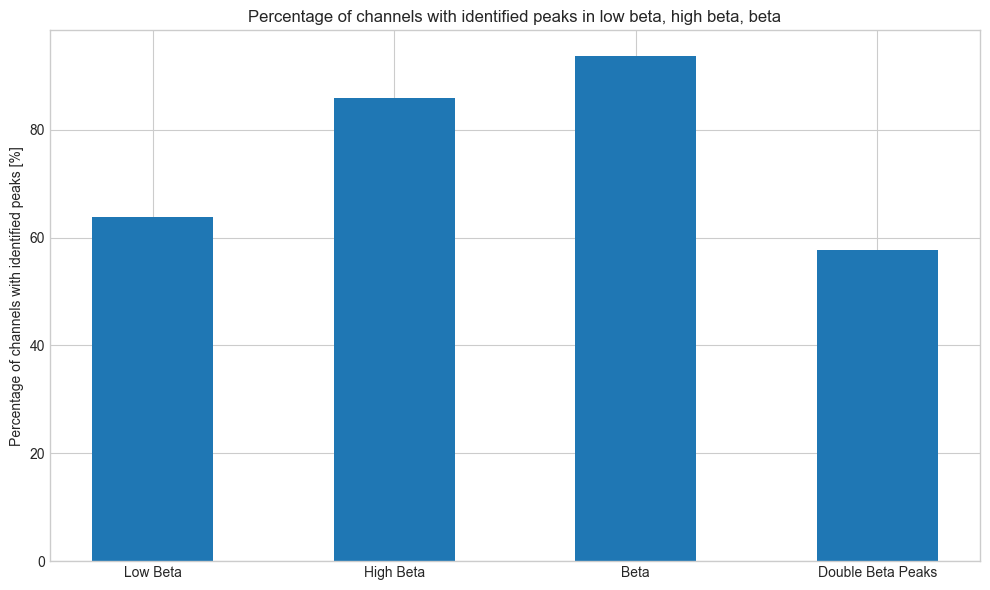

In [43]:
bar_plot = bar_plot_number_of_peaks(dataset="bipolar_beta", cohort="all_included", channel_group="all", session="all")

low beta: 41 
high beta: 54 
beta: 54 
double beta peaks: 41
total channels: 54 
low beta percentage: 75.92592592592592 
high beta percentage: 100.0 
beta percentage: 100.0 
double beta peaks percentage: 75.92592592592592


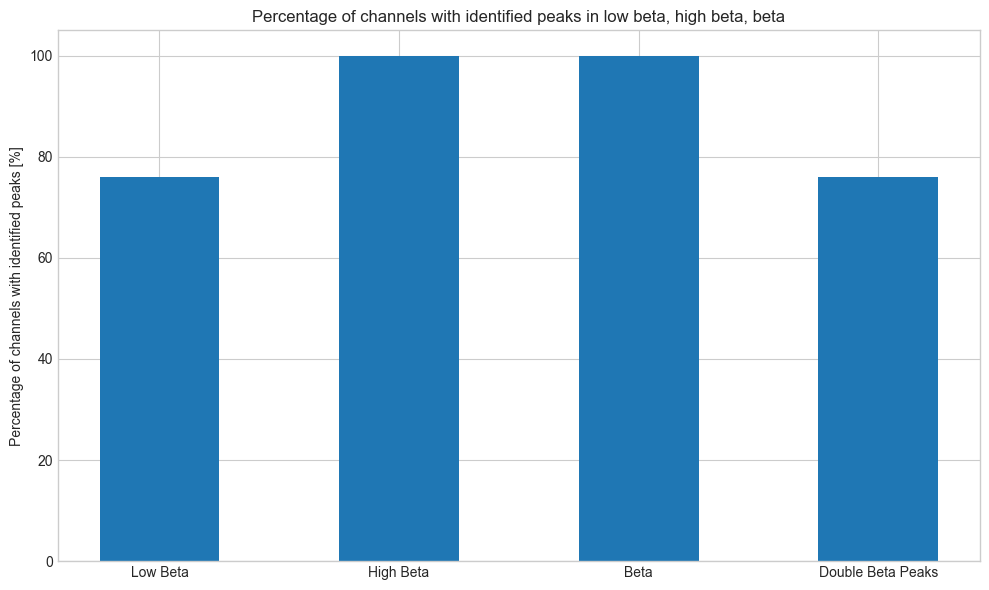

In [44]:
bar_plot = bar_plot_number_of_peaks(dataset="bipolar_highest_beta", cohort="all_included", channel_group="ring", session="fu3m")

### BIPOLAR

In [23]:
# FOOOF data only of one longterm session
# 12 LFP channels per STN

selected_fooof_data = loadResults.select_fooof_data(data="bipolar_beta",cohort="all_included")

# beta_rank_DF = loadResults.load_fooof_beta_ranks(
#         fooof_spectrum="periodic_spectrum",
#         fooof_version="v2",
#         all_or_one_chan="beta_ranks_all",
#         all_or_one_longterm_ses="one_longterm_session",
#     )

selected_fooof_data["fooof_data"]

,index,subject_hemisphere,session,bipolar_channel,fooof_error,fooof_r_sq,fooof_exponent,fooof_offset,fooof_power_spectrum,periodic_plus_aperiodic_power_log,fooof_periodic_flat,fooof_number_peaks,alpha_peak_CF_power_bandWidth,low_beta_peak_CF_power_bandWidth,high_beta_peak_CF_power_bandWidth,beta_peak_CF_power_bandWidth,gamma_peak_CF_power_bandWidth,beta_average,beta_rank
0,3,017_Right,fu3m,12,0.07857,0.972904,1.343522,0.757904,"[0.0003292927862230677, 0.0003079802974601531,...","[0.35352735458664525, 0.11698373243642358, -0....","[6.336812502902425e-05, 0.00010218204803303865...",4,"[nan, nan, nan]","[nan, nan, nan]","[29.43438184459086, 1.099716477148555, 4.71406...","[29.43438184459086, 1.099716477148555, 4.71406...","[nan, nan, nan]",0.204537,1.0
1,4,017_Right,fu3m,01,0.071117,0.979469,1.587926,1.157176,"[0.0260612717972748, 0.08068602780119916, 0.20...","[0.6815260508032184, 0.4132884933120965, 0.253...","[0.0023628423792285266, 0.01374512167041695, 0...",4,"[nan, nan, nan]","[nan, nan, nan]","[33.50000000000001, 0.34359567811682745, 3.000...","[33.50000000000001, 0.34359567811682745, 3.000...","[64.15854737876835, 0.19383025351969008, 10.73...",0.030401,3.0
2,5,017_Right,fu3m,23,0.075302,0.975031,1.291468,0.634505,"[3.658637837133938e-10, 8.781297688997824e-09,...","[0.24573455686045234, 0.018318407410551848, -0...","[9.023380458332988e-11, 3.6561550966272852e-09...",3,"[nan, nan, nan]","[13.602286189596768, 0.49020364390555904, 3.46...","[30.219295965656492, 1.0778976327745415, 6.289...","[30.219295965656492, 1.0778976327745415, 6.289...","[nan, nan, nan]",0.193264,2.0
0,12,017_Right,fu3m,1A2A,0.086413,0.969713,1.477671,1.203942,"[1.051259040174557e-05, 9.481947880196628e-06,...","[0.7591189582797522, 0.4989144774934115, 0.314...","[7.950153134128949e-07, 1.3054734695782597e-06...",3,"[nan, nan, nan]","[nan, nan, nan]","[30.823647968559502, 1.0136923869600145, 7.425...","[30.823647968559502, 1.0136923869600145, 7.425...","[nan, nan, nan]",0.277904,1.0
1,13,017_Right,fu3m,1B2B,0.074097,0.965587,1.172131,0.590142,"[0.008637710295463563, 0.008756105291477745, 0...","[0.23946149626184762, 0.034419922498690476, -0...","[0.0021667278346138965, 0.0035272626669674077,...",4,"[nan, nan, nan]","[17.35611052694957, 0.1139847371212338, 11.042...","[31.41707924195963, 0.9693953353238327, 4.1148...","[31.41707924195963, 0.9693953353238327, 4.1148...","[nan, nan, nan]",0.158807,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1,3502,084_Left,fu12m,1B1C,0.076788,0.983401,0.978101,0.245335,"[0.0005038499465231938, 0.0007384123248374008,...","[-0.04885760381391911, -0.22080402167686491, -...","[0.000244943318747232, 0.0005335240541929679, ...",4,"[9.9981622799823, 0.6762664664785228, 3.000000...","[16.353978561788214, 1.5158048943762776, 5.226...","[24.09033216572259, 1.2716368197309043, 10.686...","[16.353978561788214, 1.5158048943762776, 5.226...","[nan, nan, nan]",1.295708,1.0
2,3503,084_Left,fu12m,1A1C,0.075504,0.983576,1.178428,0.638322,"[0.0009981661203033454, 0.0017598972366603682,...","[0.2838050708190323, 0.07670967901597432, -0.0...","[0.00022557701688725285, 0.0006410360006592991...",4,"[9.660647498061278, 0.7113154679018833, 3.1398...","[17.133436855226847, 1.3989417688768562, 7.049...","[25.31888602833084, 1.0767303332301146, 6.7599...","[17.133436855226847, 1.3989417688768562, 7.049...","[nan, nan, nan]",1.197693,3.0
3,3504,084_Left,fu12m,2A2B,0.060017,0.98625,1.317129,0.846202,"[1.1151066719783387e-05, 0.0001408116205658949...","[0.44970804458186486, 0.2178085365765646, 0.05...","[1.7194657944788796e-06, 3.703674314544845e-05...",4,"[9.411092043077709, 0.33303177512364096, 3.000...","[17.24255752229247, 1.046541254272136, 4.81635...","[22.557323777656077, 0.8134137635139544, 3.000...","[17.24255752229247, 1.046541254272136, 4.81635...","[nan, nan, nan]",0.463299,4.0
4,3505,084_Left,fu12m,2B2C,0.074114,0.97023,0.964667,0.46308,"[0.004093678962242331, 0.0063080130345265495, ...","[0.17387975

In [25]:
# FOOOF data only of one longterm session
# only highest beta channel (rank 1) per LFP group

selected_fooof_data = loadResults.select_fooof_data(data="bipolar_highest_beta",cohort="all_included")

# beta_rank_DF = loadResults.load_fooof_beta_ranks(
#         fooof_spectrum="periodic_spectrum",
#         fooof_version="v2",
#         all_or_one_chan="highest_beta",
#         all_or_one_longterm_ses="one_longterm_session",
#     )

selected_fooof_data["fooof_data"].head()

,index,subject_hemisphere,session,bipolar_channel,fooof_error,fooof_r_sq,fooof_exponent,fooof_offset,fooof_power_spectrum,periodic_plus_aperiodic_power_log,fooof_periodic_flat,fooof_number_peaks,alpha_peak_CF_power_bandWidth,low_beta_peak_CF_power_bandWidth,high_beta_peak_CF_power_bandWidth,beta_peak_CF_power_bandWidth,gamma_peak_CF_power_bandWidth,beta_average,beta_rank
0,3,017_Right,fu3m,12,0.07857,0.972904,1.343522,0.757904,"[0.0003292927862230677, 0.0003079802974601531,...","[0.35352735458664525, 0.11698373243642358, -0....","[6.336812502902425e-05, 0.00010218204803303865...",4,"[nan, nan, nan]","[nan, nan, nan]","[29.43438184459086, 1.099716477148555, 4.71406...","[29.43438184459086, 1.099716477148555, 4.71406...","[nan, nan, nan]",0.204537,1.0
0,12,017_Right,fu3m,1A2A,0.086413,0.969713,1.477671,1.203942,"[1.051259040174557e-05, 9.481947880196628e-06,...","[0.7591189582797522, 0.4989144774934115, 0.314...","[7.950153134128949e-07, 1.3054734695782597e-06...",3,"[nan, nan, nan]","[nan, nan, nan]","[30.823647968559502, 1.0136923869600145, 7.425...","[30.823647968559502, 1.0136923869600145, 7.425...","[nan, nan, nan]",0.277904,1.0
5,11,017_Right,fu3m,2A2C,0.070059,0.975923,1.279358,0.622745,"[1.3979065716096528e-06, 2.5015002960149246e-0...","[0.2376206914896252, 0.01233768192489373, -0.1...","[3.512707128119114e-07, 1.0559606045368374e-06...",4,"[nan, nan, nan]","[13.59303036339205, 0.12463061825765231, 3.000...","[28.344306091350532, 0.9307513411542273, 9.686...","[28.344306091350532, 0.9307513411542273, 9.686...","[nan, nan, nan]",0.172262,1.0
2,20,017_Right,fu12m,23,0.064378,0.989523,1.700796,1.440666,"[2.6991400101650243e-05, 5.4799935694127555e-0...","[0.9286766131841131, 0.6291855485581883, 0.416...","[1.3814456454305008e-06, 5.589611276521289e-06...",4,"[nan, nan, nan]","[13.805828105459103, 0.7460678514380996, 3.064...","[28.513423058870664, 0.9111804619360752, 5.374...","[28.513423058870664, 0.9111804619360752, 5.374...","[nan, nan, nan]",0.516692,1.0
0,27,017_Right,fu12m,1A2A,0.054754,0.98773,1.600978,1.328914,"[0.0011917227674977937, 0.0012032524253271504,...","[0.8470456604000512, 0.5651960382547497, 0.365...","[7.36123518097955e-05, 0.00014223816337737217,...",4,"[nan, nan, nan]","[nan, nan, nan]","[27.185455000237216, 0.41889408694839625, 12.0...","[27.185455000237216, 0.41889408694839625, 12.0...","[63.12950075977409, 0.2016035648850072, 3.0000...",0.111572,1.0


### MONOPOLAR

In [86]:
selected_fooof_data = loadResults.select_fooof_data(dataset="monopolar_beta",cohort="all_included")

# loaded_fooof_monopolar = loadResults.load_pickle_group_result(
#         filename=f"fooof_monoRef_all_contacts_weight_beta_psd_by_inverse_sq_distance_v2",
#         fooof_version="v2",
#     )

selected_fooof_data["fooof_data"].loc[selected_fooof_data["fooof_data"]["subject_hemisphere"] == "017_Right"]

,index,coord_z,coord_xy,session,subject_hemisphere,estimated_monopolar_beta_psd,contact,beta_relative_to_max,beta_cluster,rank_8,beta_psd_rel_to_rank1,beta_psd_rel_range_0_to_1,subject
24,416,2.0+0.0j,0.650000+0.000000j,fu3m,017_Right,0.865548,1A,0.599964,2,4.0,0.599964,0.542814,017
25,417,2.0+0.0j,-0.325000+0.562917j,fu3m,017_Right,0.802782,1B,0.556457,2,6.0,0.556457,0.493091,017
26,418,2.0+0.0j,-0.325000-0.562917j,fu3m,017_Right,0.844396,1C,0.585302,2,5.0,0.585302,0.526057,017
27,419,4.0+0.0j,0.650000+0.000000j,fu3m,017_Right,1.442667,2A,1.000000,1,1.0,1.000000,1.000000,017
28,420,4.0+0.0j,-0.325000+0.562917j,fu3m,017_Right,1.189430,2B,0.824466,1,3.0,0.824466,0.799389,017
29,421,4.0+0.0j,-0.325000-0.562917j,fu3m,017_Right,1.279271,2C,0.886740,1,2.0,0.886740,0.870560,017
30,752,0.0+0.0j,0.000000+0.000000j,fu3m,017_Right,0.180339,0,0.125004,3,8.0,0.125004,0.000000,017
31,753,6.0+0.0j,0.000000+0.000000j,fu3m,017_Right,0.401397,3,0.278233,3,7.0,0.278233,0.175120,017
32,864,2.0+0.0j,0.650000+0.000000j,fu12m,017_Right,0.459436,1A,0.541168,2,6.0,0.541168,0.404618,017
33,865,2.0+0.0j,-0.325000+0.562917j,fu12m,017_Right,0.353771,1B,0.416706,2,7.0,0.416706,0.243115,017


## Spatial distribution: Bipolar LFPs

Find original functions in Permutation_rankings.py

file:  revision_group_1_bipolar_LFPs_beta_correlations_per_stn.xlsx 
written in:  /Users/jenniferbehnke/Dropbox/work/ResearchProjects/BetaSenSightLongterm/results


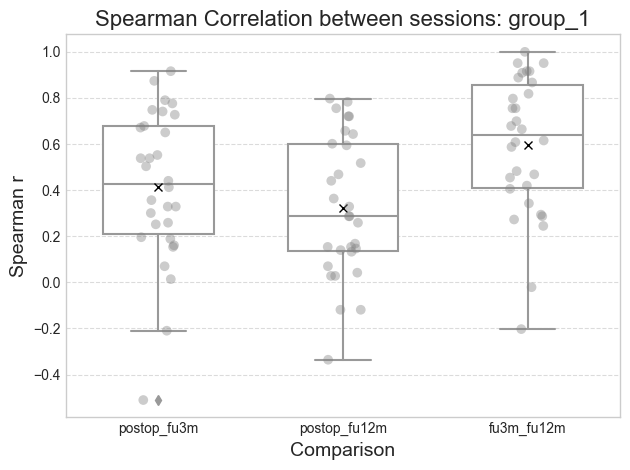

In [378]:
spearman = spatial_distribution.plot_boxplot_spearman_r_values(cohort="group_1", all_groups_together="yes")

In [173]:
spearman["spearman_result_df"]

,comparison,channel_group,sample_size_stn,standard_deviation_spearman_values,mean_spearman_values,median_spearman_values,fisher_transformation_spearman_r,standard_deviation_pval,mean_pval,median_pval,session_1,session_2
postop_postop_all_LFPs,postop_postop,all_LFPs,30,0.0,1.0,1.0,"[11.859499013855018, 11.859499013855018, 11.85...",0.0,0.0,0.0,postop,postop
postop_fu3m_all_LFPs,postop_fu3m,all_LFPs,30,0.323403,0.414918,0.426573,"[0.15507746415191975, 0.8259987634264484, 0.77...",0.270862,0.249874,0.123446,postop,fu3m
postop_fu12m_all_LFPs,postop_fu12m,all_LFPs,30,0.300527,0.323776,0.286713,"[-0.11944595414117448, 0.7881199215122522, 0.0...",0.324012,0.378832,0.331578,postop,fu12m
fu3m_postop_all_LFPs,fu3m_postop,all_LFPs,30,0.323403,0.414918,0.426573,"[0.15507746415191975, 0.8259987634264484, 0.77...",0.270862,0.249874,0.123446,fu3m,postop
fu3m_fu3m_all_LFPs,fu3m_fu3m,all_LFPs,30,0.0,1.0,1.0,"[11.859499013855018, 11.859499013855018, 11.85...",0.0,0.0,0.0,fu3m,fu3m
fu3m_fu12m_all_LFPs,fu3m_fu12m,all_LFPs,30,0.29747,0.594172,0.63986,"[0.6737062867878416, 1.4129166183792974, 0.825...",0.215153,0.140562,0.025811,fu3m,fu12m
fu12m_postop_all_LFPs,fu12m_postop,all_LFPs,30,0.300527,0.323776,0.286713,"[-0.11944595414117448, 0.7881199215122522, 0.0...",0.324012,0.378832,0.331578,fu12m,postop
fu12m_fu3m_all_LFPs,fu12m_fu3m,all_LFPs,30,0.29747,0.594172,0.63986,"[0.6737062867878416, 1.4129166183792974, 0.825...",0.215153,0.140562,0.025811,fu12m,fu3m
fu12m_fu12m_all_LFPs,fu12m_fu12m,all_LFPs,30,0.0,1.0,1.0,"[11.859499013855018, 11.859499013855018, 11.85...",0.0,0.0,0.0,fu12m,fu12m


file:  revision_group_1_bipolar_LFPs_beta_correlations_per_stn.xlsx 
written in:  /Users/jenniferbehnke/Dropbox/work/ResearchProjects/BetaSenSightLongterm/results
Figures revision_t-test_fisher_transformed_Spearman_coeff_None_bipolar_group_1_all_LFPs.svg and revision_t-test_fisher_transformed_Spearman_coeff_None_bipolar_group_1_all_LFPs.png 
were written in: /Users/jenniferbehnke/Dropbox/work/ResearchProjects/BetaSenSightLongterm/figures.


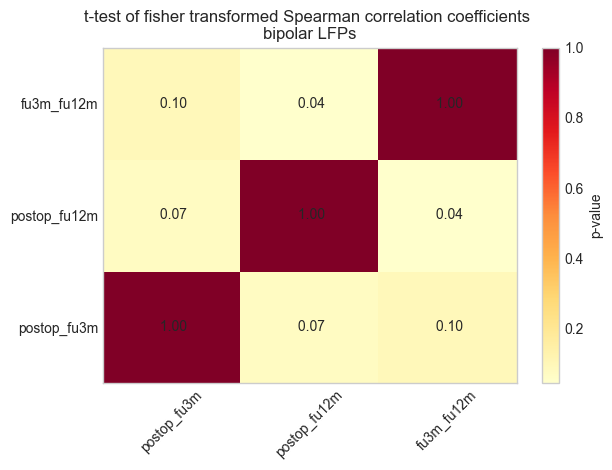

In [400]:
t_test_result = spatial_distribution.t_test_fisher_transformed_correlation_coeff(cohort="group_1", all_groups_together="yes", correction=None)

In [401]:
t_test_result["t-test_results"]

,comparison_1,comparison_2,statistic,p-value
postop_fu3m_vs_postop_fu12m,postop_fu3m,postop_fu12m,1.87565,0.070804
postop_fu3m_vs_fu3m_fu12m,postop_fu3m,fu3m_fu12m,-1.719726,0.096139
postop_fu12m_vs_postop_fu3m,postop_fu12m,postop_fu3m,-1.87565,0.070804
postop_fu12m_vs_fu3m_fu12m,postop_fu12m,fu3m_fu12m,-2.102728,0.044284
fu3m_fu12m_vs_postop_fu3m,fu3m_fu12m,postop_fu3m,1.719726,0.096139
fu3m_fu12m_vs_postop_fu12m,fu3m_fu12m,postop_fu12m,2.102728,0.044284


In [385]:
t_test_result["comparison_pairs"]

[(0, 1), (1, 0)]

In [386]:
t_test_result["all_p_values"]

[0.6959785629097512, 0.6959785629097512]

In [178]:
t_test_result["corrected_p_values"]

array([0.28321401, 0.28321401, 0.28321401, 0.26570682, 0.28321401,
       0.26570682])

In [179]:
t_test_result["comparison_matrix"]

array([[1.        , 0.28321401, 0.28321401],
       [0.28321401, 1.        , 0.26570682],
       [0.28321401, 0.26570682, 1.        ]])

## Spatial distribution: Monopolar

In [ ]:
fooof_spearman_correlation = groupMonopol.fooof_monopol_psd_spearman_betw_sessions(
    mean_or_median="mean",
    only_segmental="no",
    values_to_correlate="not_normalized",
    similarity_calculation="inverse_sq_distance",
    fooof_version="v2"
)

In [270]:
monopolar = spatial_distribution.fooof_monopol_psd_spearman_betw_sessions(
    cohort="group_3",
    mean_or_median="mean",
    only_segmental="yes",
    values_to_correlate="not_normalized",
    similarity_calculation="inverse_sq_distance",
    fooof_version="v2")

only segmental contacts included
only segmental contacts included
only segmental contacts included
only segmental contacts included
only segmental contacts included
only segmental contacts included
only segmental contacts included
only segmental contacts included
only segmental contacts included
only segmental contacts included
only segmental contacts included
only segmental contacts included
only segmental contacts included
only segmental contacts included
only segmental contacts included
only segmental contacts included
file:  revision_fooof_monopol_inverse_sq_distance_beta_correlations_per_stn_v2.xlsx 
written in:  /Users/jenniferbehnke/Dropbox/work/ResearchProjects/BetaSenSightLongterm/results


only segmental contacts included
only segmental contacts included
only segmental contacts included
only segmental contacts included
only segmental contacts included
only segmental contacts included
only segmental contacts included
only segmental contacts included
only segmental contacts included
file:  revision_fooof_monopol_inverse_sq_distance_beta_correlations_per_stn_v2.xlsx 
written in:  /Users/jenniferbehnke/Dropbox/work/ResearchProjects/BetaSenSightLongterm/results


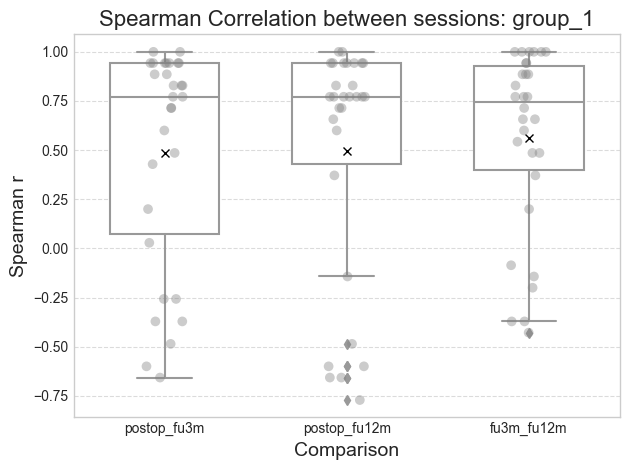

In [398]:
plot_monopolar = spatial_distribution.plot_boxplot_monopolar_spearman_r_values(cohort="group_1", only_segmental="yes")

In [389]:
plot_monopolar["spearman_result_df"]

,session_1,session_2,session_comparison,mean_spearmanr,mean_pval,spearman_std,sample_size
postop_postop_spearman_m,postop,postop,postop_postop,1.0,0.0,0.0,30
postop_fu3m_spearman_m,postop,fu3m,postop_fu3m,0.485714,0.201073,0.555002,30
postop_fu12m_spearman_m,postop,fu12m,postop_fu12m,0.493333,0.119813,0.601265,30
fu3m_postop_spearman_m,fu3m,postop,fu3m_postop,0.485714,0.201073,0.555002,30
fu3m_fu3m_spearman_m,fu3m,fu3m,fu3m_fu3m,1.0,0.0,0.0,30
fu3m_fu12m_spearman_m,fu3m,fu12m,fu3m_fu12m,0.56,0.224934,0.461916,30
fu12m_postop_spearman_m,fu12m,postop,fu12m_postop,0.493333,0.119813,0.601265,30
fu12m_fu3m_spearman_m,fu12m,fu3m,fu12m_fu3m,0.56,0.224934,0.461916,30
fu12m_fu12m_spearman_m,fu12m,fu12m,fu12m_fu12m,1.0,0.0,0.0,30


In [287]:
plot_monopolar["single_stn_spearman_DF_copy"].head()

,session_comparison,subject_hemisphere,spearman_r,pval,significant_correlation
fu3m_fu12m_017_Left,fu3m_fu12m,017_Left,0.380952,0.351813,no
fu3m_fu12m_017_Right,fu3m_fu12m,017_Right,0.571429,0.13896,no
fu3m_fu12m_019_Left,fu3m_fu12m,019_Left,1.0,0.0,yes
fu3m_fu12m_019_Right,fu3m_fu12m,019_Right,0.452381,0.260405,no
fu3m_fu12m_021_Left,fu3m_fu12m,021_Left,0.833333,0.010176,yes


In [390]:
plot_monopolar["significant_correlations"]

{'postop_fu3m': (14, 46.666666666666664),
 'postop_fu12m': (11, 36.666666666666664),
 'fu3m_fu12m': (12, 40.0)}

all contacts included
all contacts included
all contacts included
all contacts included
all contacts included
all contacts included
all contacts included
all contacts included
all contacts included
file:  revision_fooof_monopol_inverse_sq_distance_beta_correlations_per_stn_v2.xlsx 
written in:  /Users/jenniferbehnke/Dropbox/work/ResearchProjects/BetaSenSightLongterm/results
Figures revision_t-test_fisher_transformed_Spearman_coeff_monoolar_only_segmental_no_None_group_1.svg and revision_t-test_fisher_transformed_Spearman_coeff_monoolar_only_segmental_no_None_group_1.png 
were written in: /Users/jenniferbehnke/Dropbox/work/ResearchProjects/BetaSenSightLongterm/figures.


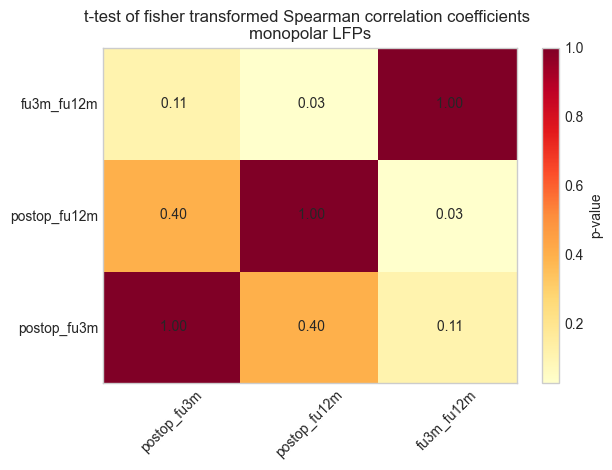

In [397]:
ttest_monopolar = spatial_distribution.t_test_fisher_transformed_spearman_monopolar(cohort="group_1", only_segmental="no", correction=None)

In [395]:
ttest_monopolar["all_p_values"]

[0.11378596903112481, 0.11378596903112481]

In [294]:
list(ttest_monopolar["corrected_p_values"])

[0.7966038601142604,
 0.45514387612449925,
 0.7966038601142604,
 0.17050907612891428,
 0.45514387612449925,
 0.17050907612891428]

In [295]:
ttest_monopolar["comparison_pairs"]

[(0, 1), (0, 2), (1, 0), (1, 2), (2, 0), (2, 1)]

In [292]:
ttest_monopolar["spearman_group_results"]

,session_1,session_2,session_comparison,mean_spearmanr,mean_pval,spearman_std,sample_size
postop_postop_spearman_m,postop,postop,postop_postop,1.0,0.0,0.0,30
postop_fu3m_spearman_m,postop,fu3m,postop_fu3m,0.744444,0.097205,0.287227,30
postop_fu12m_spearman_m,postop,fu12m,postop_fu12m,0.736508,0.117917,0.2954,30
fu3m_postop_spearman_m,fu3m,postop,fu3m_postop,0.744444,0.097205,0.287227,30
fu3m_fu3m_spearman_m,fu3m,fu3m,fu3m_fu3m,1.0,0.0,0.0,30
fu3m_fu12m_spearman_m,fu3m,fu12m,fu3m_fu12m,0.786508,0.074745,0.213799,30
fu12m_postop_spearman_m,fu12m,postop,fu12m_postop,0.736508,0.117917,0.2954,30
fu12m_fu3m_spearman_m,fu12m,fu3m,fu12m_fu3m,0.786508,0.074745,0.213799,30
fu12m_fu12m_spearman_m,fu12m,fu12m,fu12m_fu12m,1.0,0.0,0.0,30


In [290]:
ttest_monopolar["t_test_results_df"]

,comparison_1,comparison_2,fisher_comparison_1,fisher_comparison_2,statistic,p-value
postop_fu3m_vs_postop_fu12m,postop_fu3m,postop_fu12m,"[11.859499013855018, 0.2938933324510596, 1.282...","[1.4978661367769954, -0.19283124040599237, 1.1...",2.306584,0.796604
postop_fu3m_vs_fu3m_fu12m,postop_fu3m,fu3m_fu12m,"[11.859499013855018, 0.2938933324510596, 1.282...","[1.4978661367769954, -0.19283124040599237, 1.1...",2.306584,0.455144
postop_fu12m_vs_postop_fu3m,postop_fu12m,postop_fu3m,"[11.859499013855018, 0.2938933324510596, 1.282...","[1.4978661367769954, -0.19283124040599237, 1.1...",2.306584,0.796604
postop_fu12m_vs_fu3m_fu12m,postop_fu12m,fu3m_fu12m,"[11.859499013855018, 0.2938933324510596, 1.282...","[1.4978661367769954, -0.19283124040599237, 1.1...",2.306584,0.170509
fu3m_fu12m_vs_postop_fu3m,fu3m_fu12m,postop_fu3m,"[11.859499013855018, 0.2938933324510596, 1.282...","[1.4978661367769954, -0.19283124040599237, 1.1...",2.306584,0.455144
fu3m_fu12m_vs_postop_fu12m,fu3m_fu12m,postop_fu12m,"[11.859499013855018, 0.2938933324510596, 1.282...","[1.4978661367769954, -0.19283124040599237, 1.1...",2.306584,0.170509


## Maximal beta contact positional stability

In [375]:
# write changes of beta ranks 
changes = spatial_distribution.write_df_xy_changes_of_beta_ranks(cohort="all_included", ranks_included=[1, 2])

In [376]:
changes["sample_size_dataframe"]

,session_comparison,sample_size,percentage_stable_level,percentage_stable_direction
0_0_beta_rank_1,0_0,52,1.0,1.0
0_3_beta_rank_1,0_3,40,0.7,0.675
0_12_beta_rank_1,0_12,42,0.738095,0.619048
0_18_beta_rank_1,0_18,22,0.590909,0.681818
3_0_beta_rank_1,3_0,40,0.7,0.675
3_3_beta_rank_1,3_3,54,1.0,1.0
3_12_beta_rank_1,3_12,44,0.795455,0.636364
3_18_beta_rank_1,3_18,26,0.846154,0.730769
12_0_beta_rank_1,12_0,42,0.738095,0.619048
12_3_beta_rank_1,12_3,44,0.795455,0.636364


In [366]:
changes["coord_difference_dataframe"].head()

,session_comparison,session_1,session_2,subject_hemisphere,beta_rank,contact_session_1,contact_session_2,x_difference,y_difference
0_0_024_Right_1,0_0,0,0,024_Right,1,1A,1A,0,0
0_0_024_Right_2,0_0,0,0,024_Right,2,1B,1B,0,0
0_0_024_Left_1,0_0,0,0,024_Left,1,1A,1A,0,0
0_0_024_Left_2,0_0,0,0,024_Left,2,1C,1C,0,0
0_0_025_Right_1,0_0,0,0,025_Right,1,1A,1A,0,0


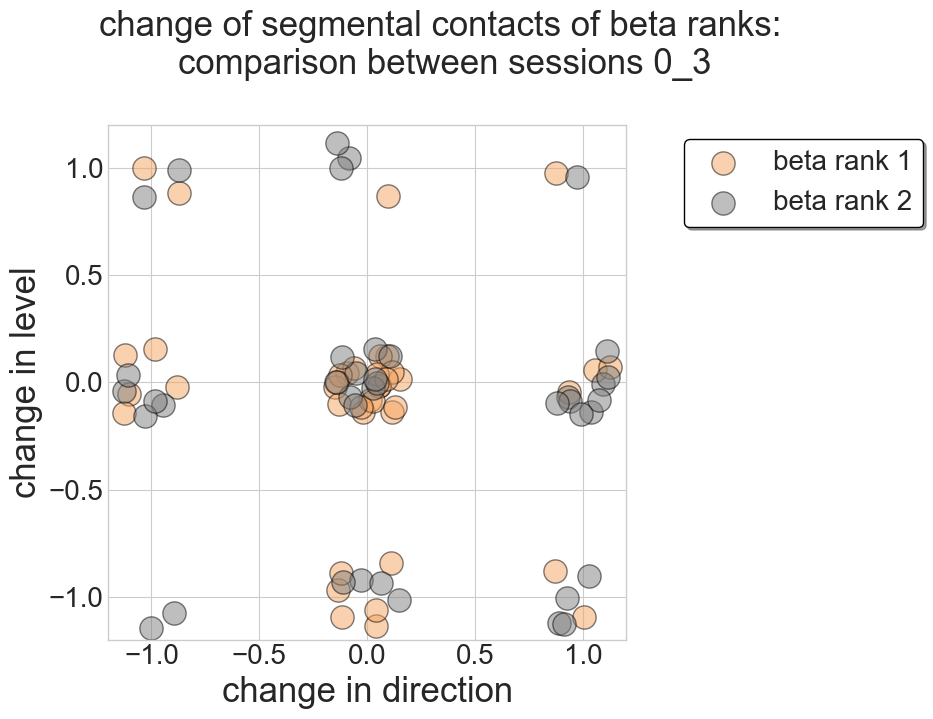

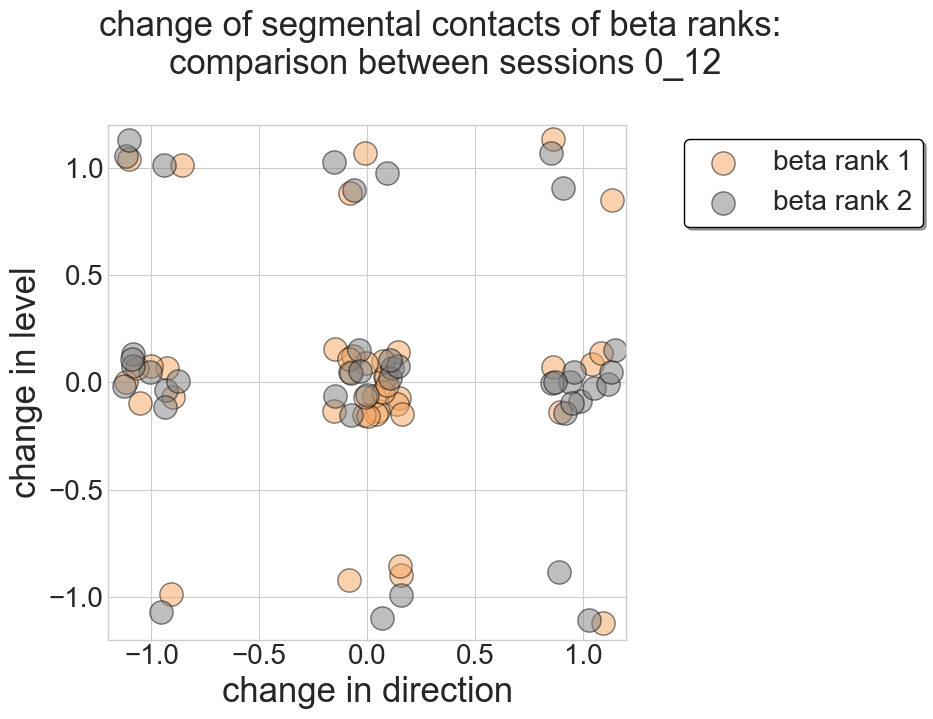

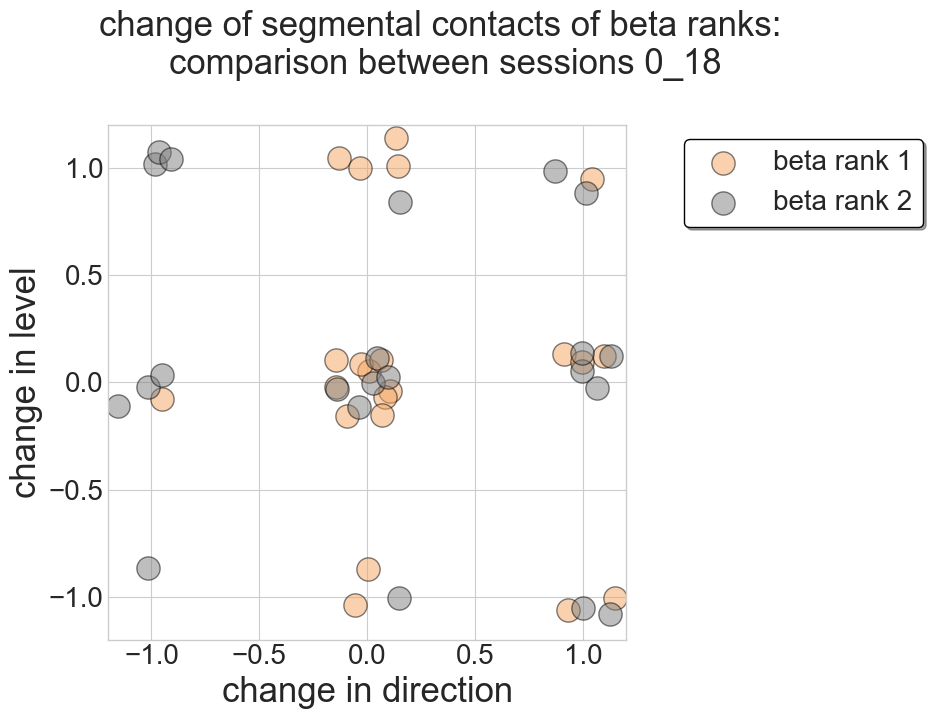

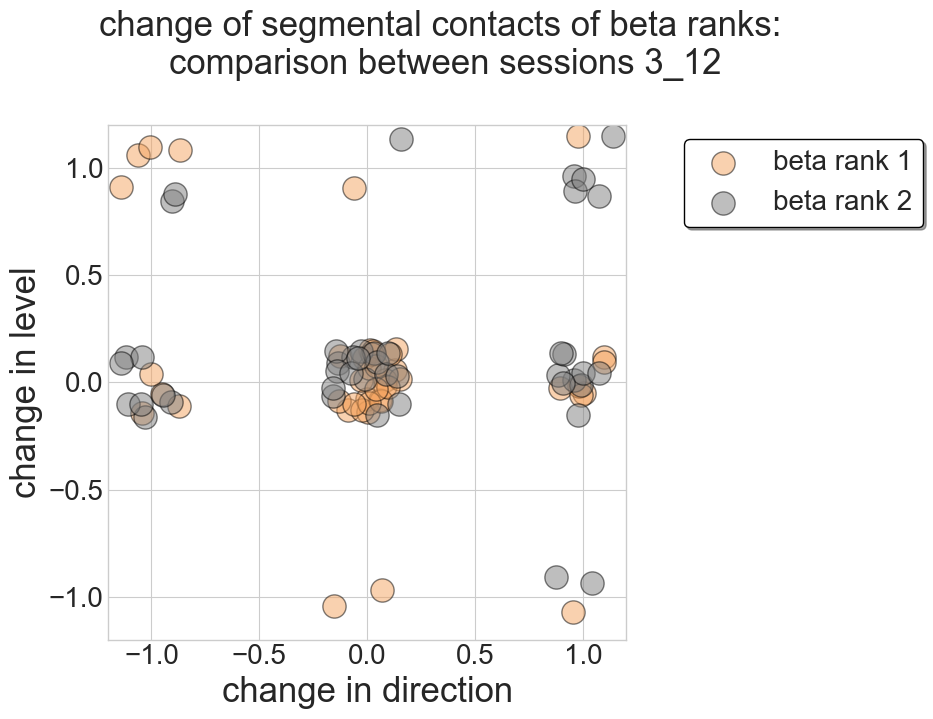

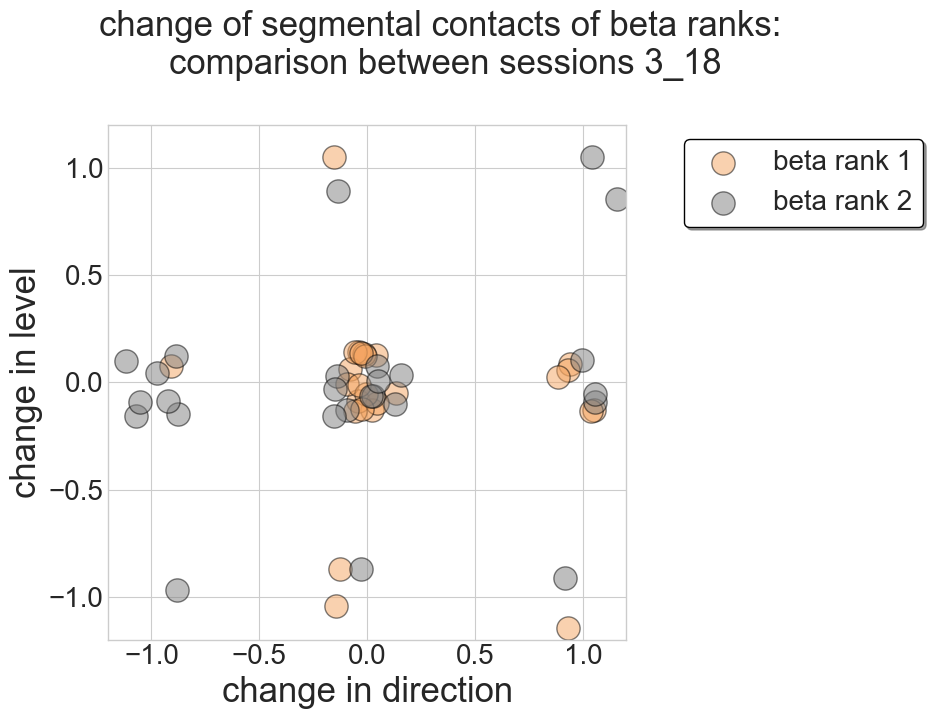

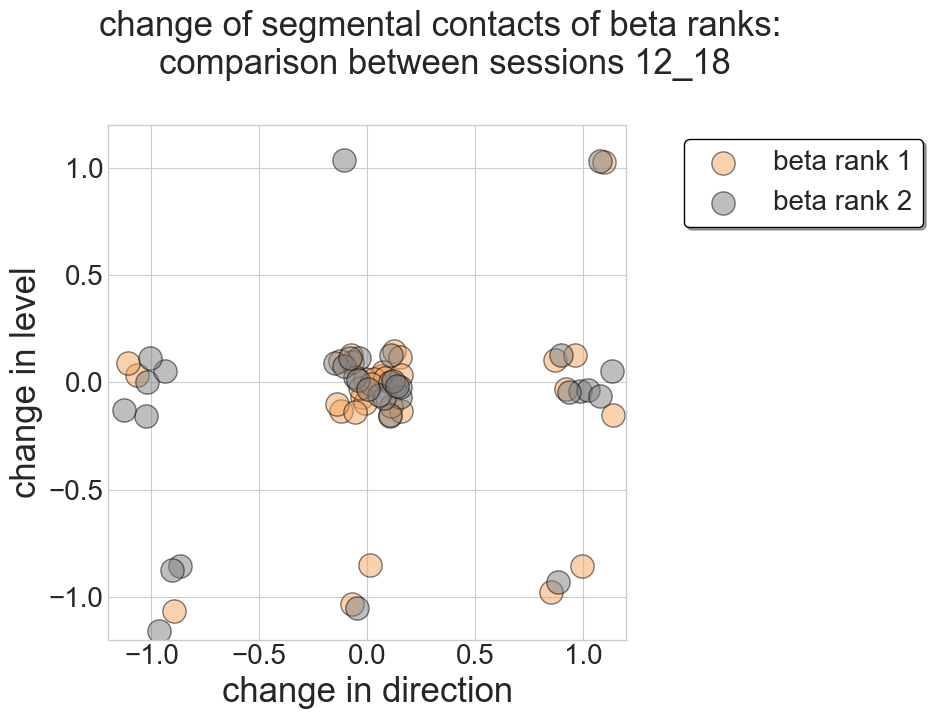

In [374]:
plot_changes = spatial_distribution.fooof_beta_rank_coord_difference_scatterplot(cohort="all_included", ranks_included=[1, 2])